# COCO Dataset Analysis

This notebook does the following:

1. Read a COCO json file and ignore images without annotations.
2. Draw a combined bar chart and line chart.
3. Draw a composite pie chart with a separate zoom panel.
4. Draw a density pie chart for object counts per image.

In [159]:
import json
from collections import Counter, defaultdict
from pathlib import Path

import random

import matplotlib.colors as mcolors
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.patches import ConnectionPatch
from PIL import Image, ImageOps

plt.rcParams['axes.unicode_minus'] = False

In [160]:
# =========================
# Manual config
# =========================

# Fill in your COCO json path here.
COCO_JSON_PATH = Path(r'E:\CCI-Colony Counting and Identification\CCI\json\instances_Train.json')

# Manual values for the second bar of each class.
# Key: class name, Value: manual number.
# Missing classes default to 0.
manual_bar_values = {"Alternaria alternata":17, 
                     "Alternaria tenuissima":10,
                     "Bacillus subtilis":22,
                     "Bacillus thaonhiensis":16,
                     "Deinococcus soli":14,
                     "Kocuria oceani":4, 
                     "Arthrobacter oryzae":12, 
                     "Micrococcus luteus":15,
                     "Staphylococcus aureus":13, 
                     "Streptomyces spororaveus":8
}

# Main pie chart values. Fill these manually.
# For a split pie, one slice in the main pie should represent the whole zoomed group.
pie_main_values = {
     'Zoomed group': 200,
     'C': 40,
}

# Which slice in the main pie should be split out to the small pie.
pie_zoom_parent_label = 'Zoomed group'

# Zoomed pie chart values. Fill these manually.
pie_zoom_values = {
     'A': 120,
     'B': 80,
}

FIG_SIZE_WIDE = (10, 6)
FIG_SIZE_NORMAL = (10, 6)

In [161]:
def load_coco_annotations(json_path: Path):
    if not str(json_path).strip():
        raise ValueError('Please fill in COCO_JSON_PATH first.')

    if not json_path.exists():
        raise FileNotFoundError(f'JSON file not found: {json_path}')

    with json_path.open('r', encoding='utf-8') as f:
        coco = json.load(f)

    images = coco.get('images', [])
    annotations = coco.get('annotations', [])
    categories = coco.get('categories', [])

    image_id_to_info = {img['id']: img for img in images}
    category_id_to_name = {cat['id']: cat['name'] for cat in categories}

    ann_by_image = defaultdict(list)
    for ann in annotations:
        image_id = ann.get('image_id')
        if image_id in image_id_to_info:
            ann_by_image[image_id].append(ann)

    annotated_image_ids = {image_id for image_id, anns in ann_by_image.items() if anns}
    valid_images = [image_id_to_info[image_id] for image_id in annotated_image_ids]

    return {
        'coco': coco,
        'images': images,
        'annotations': annotations,
        'categories': categories,
        'valid_images': valid_images,
        'annotated_image_ids': annotated_image_ids,
        'ann_by_image': ann_by_image,
        'category_id_to_name': category_id_to_name,
    }


def compute_statistics(dataset):
    ann_by_image = dataset['ann_by_image']
    category_id_to_name = dataset['category_id_to_name']

    class_image_counter = Counter()
    class_target_counter = Counter()
    image_target_density = []

    for image_id, anns in ann_by_image.items():
        if not anns:
            continue

        image_target_density.append(len(anns))

        category_id = anns[0]['category_id']
        class_name = category_id_to_name.get(category_id, f'category_{category_id}')

        class_image_counter[class_name] += 1
        class_target_counter[class_name] += len(anns)

    ordered_class_names = sorted(class_image_counter.keys())

    return {
        'ordered_class_names': ordered_class_names,
        'class_image_counter': class_image_counter,
        'class_target_counter': class_target_counter,
        'image_target_density': image_target_density,
    }

In [162]:
def plot_class_bar_line(stats, manual_values):
    class_names = stats['ordered_class_names']
    if not class_names:
        raise ValueError('No annotated data found.')

    image_counts = [stats['class_image_counter'][name] for name in class_names]
    target_counts = [stats['class_target_counter'][name] for name in class_names]
    manual_counts = [manual_values.get(name, 0) for name in class_names]

    x = np.arange(len(class_names))
    width = 0.35

    fig, ax1 = plt.subplots(figsize=FIG_SIZE_WIDE)
    bars1 = ax1.bar(x - width / 2, image_counts, width, label='image_tra_num', color="#4C78A8", edgecolor='black', linewidth=1.0)
    bars2 = ax1.bar(x + width / 2, manual_counts, width, label='image_tot_num', color='#F58518', edgecolor='black', linewidth=1.0)

    ax1.set_xlabel('Class')
    ax1.set_ylabel('Photo num')
    ax1.set_title('Purely Cultivated Dataset Situation')
    ax1.set_xticks(x)
    ax1.set_xticklabels(class_names, rotation=45, ha='right')

    ax2 = ax1.twinx()
    ax2.plot(x, target_counts, color="#FF0000", marker='o', linewidth=2, label='target_count')
    ax2.set_ylabel('Total object count')

    for bar in bars1:
        height = bar.get_height()
        ax1.text(bar.get_x() + bar.get_width() / 2, height, f'{int(height)}', ha='center', va='bottom', fontsize=9)

    for bar in bars2:
        height = bar.get_height()
        if height > 0:
            ax1.text(bar.get_x() + bar.get_width() / 2, height, f'{int(height)}', ha='center', va='bottom', fontsize=9)

    for idx, value in enumerate(target_counts):
        ax2.text(x[idx], value, f'{int(value)}', ha='center', va='bottom', fontsize=9, color="#FF0000")

    handles1, labels1 = ax1.get_legend_handles_labels()
    handles2, labels2 = ax2.get_legend_handles_labels()
    ax1.legend(handles1 + handles2, labels1 + labels2, loc='upper left')

    plt.tight_layout()
    plt.show()


def plot_composite_pie(main_values, zoom_values, zoom_parent_label=None):
    if not main_values:
        raise ValueError('Please fill in pie_main_values first.')

    main_labels = list(main_values.keys())
    main_sizes = list(main_values.values())

    if zoom_values and not zoom_parent_label:
        raise ValueError('Please fill in pie_zoom_parent_label for the split slice.')

    if zoom_values and zoom_parent_label not in main_values:
        raise ValueError(f"'{zoom_parent_label}' is not a key in pie_main_values.")

    if zoom_values:
        fig, (ax_main, ax_zoom) = plt.subplots(1, 2, figsize=(14, 6))
    else:
        fig, ax_main = plt.subplots(figsize=(8, 6))
        ax_zoom = None

    colors = plt.cm.Set3(np.linspace(0, 1, len(main_labels)))
    explode = [0.08 if label == zoom_parent_label else 0 for label in main_labels]

    wedges, _, _ = ax_main.pie(
        main_sizes,
        labels=main_labels,
        autopct='%1.1f%%',
        startangle=90,
        colors=colors,
        explode=explode,
        wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
    )
    ax_main.set_title('Main Pie')
    ax_main.axis('equal')

    if zoom_values:
        zoom_labels = list(zoom_values.keys())
        zoom_sizes = list(zoom_values.values())
        zoom_colors = plt.cm.Pastel1(np.linspace(0, 1, len(zoom_labels)))
        zoom_total = sum(zoom_sizes)
        parent_value = main_values[zoom_parent_label]

        if abs(parent_value - zoom_total) > 1e-9:
            print(
                f"Warning: pie_main_values['{zoom_parent_label}'] = {parent_value}, "
                f"but sum(pie_zoom_values) = {zoom_total}."
            )

        ax_zoom.pie(
            zoom_sizes,
            labels=zoom_labels,
            autopct='%1.1f%%',
            startangle=90,
            colors=zoom_colors,
            wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
        )
        ax_zoom.set_title('Zoom Pie', fontsize=11)
        ax_zoom.axis('equal')

        parent_index = main_labels.index(zoom_parent_label)
        wedge = wedges[parent_index]
        theta1 = np.deg2rad(wedge.theta1)
        theta2 = np.deg2rad(wedge.theta2)

        center_x, center_y = wedge.center
        radius = wedge.r

        x1 = center_x + radius * np.cos(theta1)
        y1 = center_y + radius * np.sin(theta1)
        x2 = center_x + radius * np.cos(theta2)
        y2 = center_y + radius * np.sin(theta2)

        con1 = ConnectionPatch(
            xyA=(-1.0, 1.0), coordsA=ax_zoom.transData,
            xyB=(x1, y1), coordsB=ax_main.transData,
            color='gray', linewidth=1.5
        )
        con2 = ConnectionPatch(
            xyA=(-1.0, -1.0), coordsA=ax_zoom.transData,
            xyB=(x2, y2), coordsB=ax_main.transData,
            color='gray', linewidth=1.5
        )
        fig.add_artist(con1)
        fig.add_artist(con2)

    plt.tight_layout()
    plt.show()


def plot_density_pie(stats):
    density_list = stats['image_target_density']
    if not density_list:
        raise ValueError('No annotated images found.')

    density_bins = {
        '1-20': 0,
        '21-50': 0,
        '51-200': 0,
        '>200': 0,
    }

    for count in density_list:
        if 1 <= count <= 20:
            density_bins['1-20'] += 1
        elif 21 <= count <= 50:
            density_bins['21-50'] += 1
        elif 51 <= count <= 200:
            density_bins['51-200'] += 1
        elif count > 200:
            density_bins['>200'] += 1

    labels = list(density_bins.keys())
    values = list(density_bins.values())

    plt.figure(figsize=FIG_SIZE_NORMAL)
    plt.pie(
        values,
        labels=labels,
        autopct='%1.1f%%',
        startangle=90,
        colors=['#4C78A8', '#F58518', '#54A24B', '#E45756'],
        wedgeprops={'linewidth': 1, 'edgecolor': 'white'}
    )
    plt.title('Image Count by Object Density Range')
    plt.axis('equal')

    plt.tight_layout()
    plt.show()

    return density_bins

In [163]:
dataset = load_coco_annotations(COCO_JSON_PATH)
stats = compute_statistics(dataset)

print(f"Total images: {len(dataset['images'])}")
print(f"Annotated images: {len(dataset['valid_images'])}")
print(f"Total annotations: {len(dataset['annotations'])}")
print(f"Classes in use: {len(stats['ordered_class_names'])}")

print('\nImage count per class:')
for class_name in stats['ordered_class_names']:
    print(f"  {class_name}: {stats['class_image_counter'][class_name]}")

print('\nObject count per class:')
for class_name in stats['ordered_class_names']:
    print(f"  {class_name}: {stats['class_target_counter'][class_name]}")

Total images: 135
Annotated images: 77
Total annotations: 3986
Classes in use: 10

Image count per class:
  Alternaria alternata: 13
  Alternaria tenuissima: 10
  Arthrobacter oryzae: 2
  Bacillus subtilis: 14
  Bacillus thaonhiensis: 16
  Deinococcus soli: 5
  Kocuria oceani: 4
  Micrococcus luteus: 3
  Staphylococcus aureus: 6
  Streptomyces spororaveus: 4

Object count per class:
  Alternaria alternata: 201
  Alternaria tenuissima: 80
  Arthrobacter oryzae: 549
  Bacillus subtilis: 372
  Bacillus thaonhiensis: 142
  Deinococcus soli: 906
  Kocuria oceani: 453
  Micrococcus luteus: 612
  Staphylococcus aureus: 415
  Streptomyces spororaveus: 256


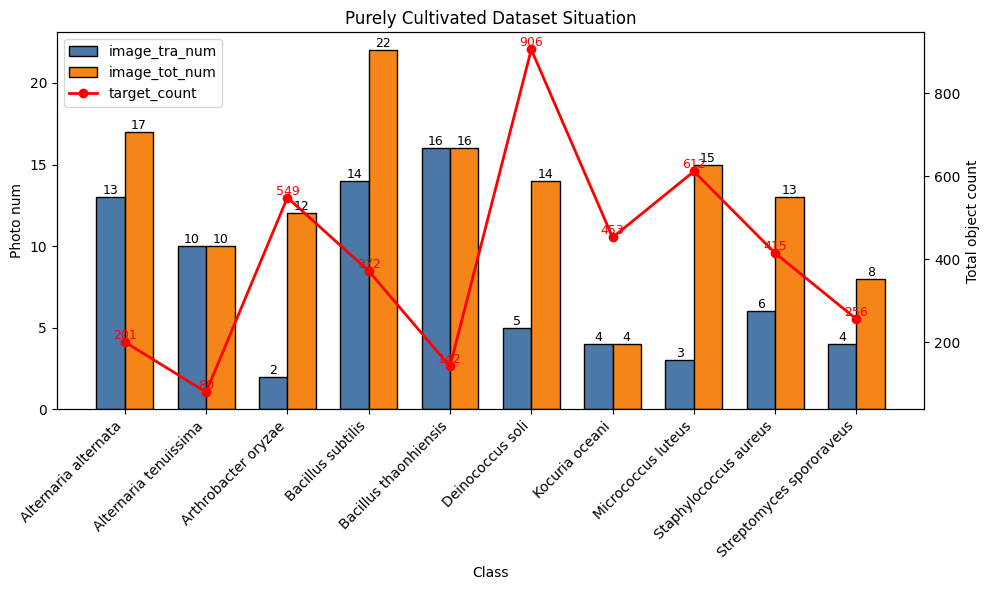

In [164]:
plot_class_bar_line(stats, manual_bar_values)

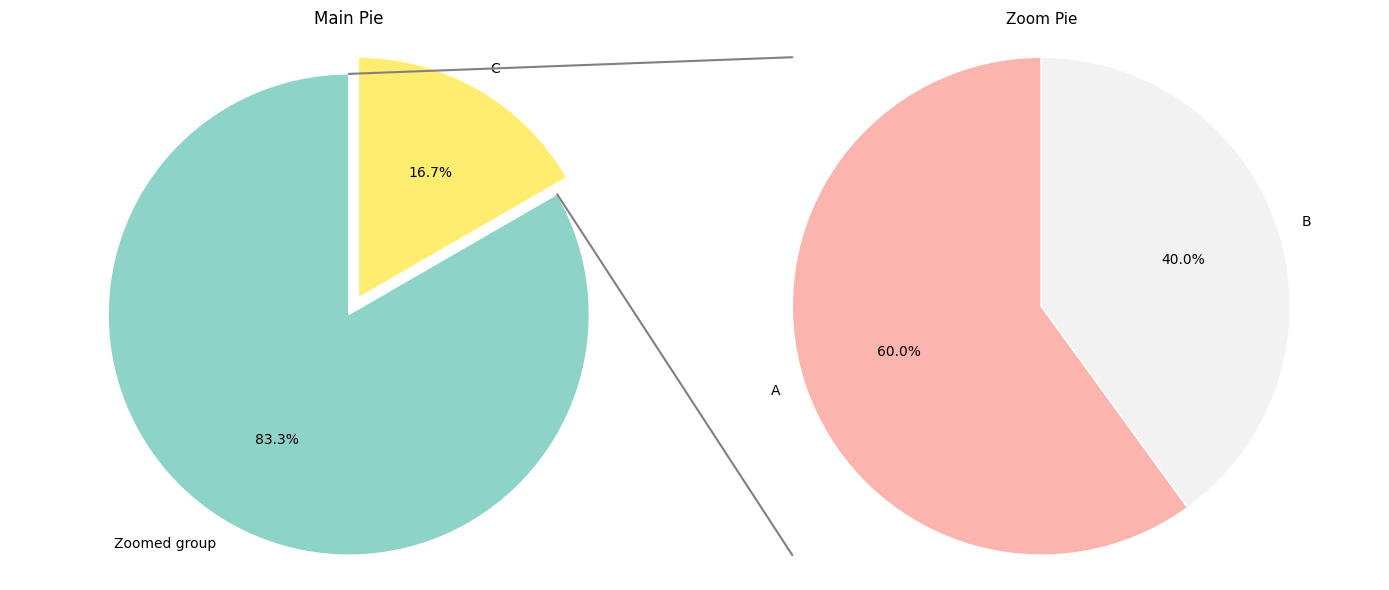

In [165]:
plot_composite_pie(pie_main_values, pie_zoom_values, pie_zoom_parent_label)

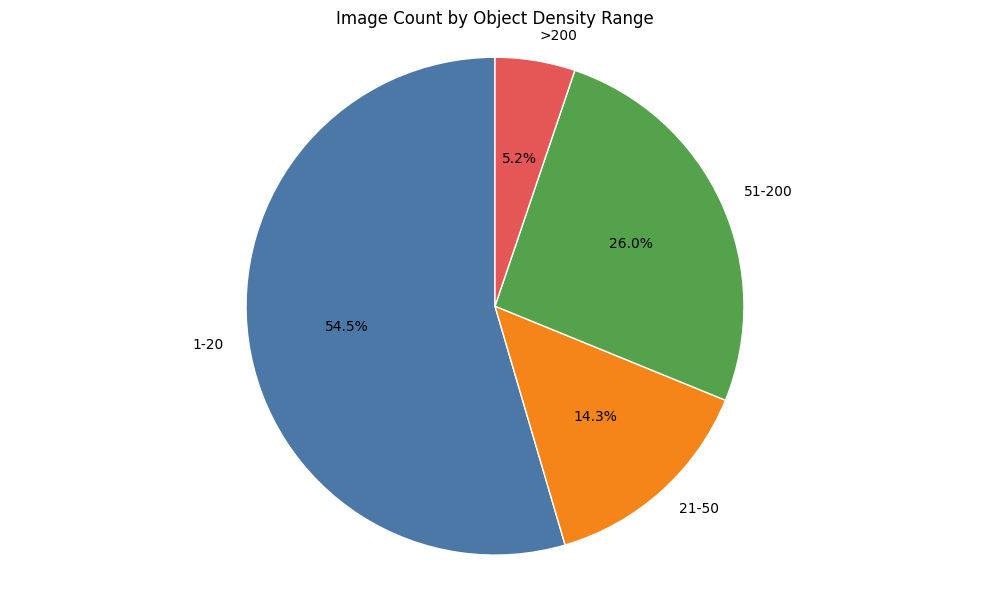

{'1-20': 42, '21-50': 11, '51-200': 20, '>200': 4}

In [166]:
density_result = plot_density_pie(stats)
density_result

## Single Image Augmentation Demo

Fill in one image path below. The augmentation is only an approximate visual demo of the provided params.

In [167]:
IMAGE_DEMO_PATH = Path(r'D:\dataset_pre\ht\1.jpg')
DEMO_AUG_SEED = 42

AUG_PARAMS = {
    'hsv_h': 0.01,
    'hsv_s': 0.3,
    'hsv_v': 0.6,
    'degrees': 180.0,
    'translate': 0.1,
    'scale': 0.5,
    'shear': 5.0,
    'perspective': 0.001,
    'flipud': 0.2,
    'fliplr': 0.5,
    'mosaic': 0.8,
    'mixup': 0.2,
    'cutmix': 0.0,
    'bgr': 0.0,
}

In [168]:
RESAMPLE = Image.Resampling.BICUBIC if hasattr(Image, 'Resampling') else Image.BICUBIC
FILL_COLOR = (114, 114, 114)


def load_demo_image(image_path: Path):
    if not str(image_path).strip():
        raise ValueError('Please fill in IMAGE_DEMO_PATH first.')
    if not image_path.exists():
        raise FileNotFoundError(f'Image file not found: {image_path}')
    return Image.open(image_path).convert('RGB')


def apply_hsv_lighting(img, params, rng):
    arr = np.asarray(img).astype(np.float32) / 255.0
    hsv = mcolors.rgb_to_hsv(arr)
    hsv[..., 0] = (hsv[..., 0] + rng.uniform(-params['hsv_h'], params['hsv_h'])) % 1.0
    hsv[..., 1] = np.clip(hsv[..., 1] * (1 + rng.uniform(-params['hsv_s'], params['hsv_s'])), 0, 1)
    hsv[..., 2] = np.clip(hsv[..., 2] * (1 + rng.uniform(-params['hsv_v'], params['hsv_v'])), 0, 1)
    rgb = (mcolors.hsv_to_rgb(hsv) * 255).astype(np.uint8)
    return Image.fromarray(rgb)


def apply_affine_like_transform(img, params, rng):
    w, h = img.size
    angle = rng.uniform(-params['degrees'], params['degrees'])
    scale_factor = max(0.2, 1 + rng.uniform(-params['scale'], params['scale']))
    shear_deg = rng.uniform(-params['shear'], params['shear'])
    tx = int(rng.uniform(-params['translate'], params['translate']) * w)
    ty = int(rng.uniform(-params['translate'], params['translate']) * h)

    scaled = img.resize((max(1, int(w * scale_factor)), max(1, int(h * scale_factor))), RESAMPLE)
    canvas = Image.new('RGB', (w, h), FILL_COLOR)
    paste_x = (w - scaled.width) // 2 + tx
    paste_y = (h - scaled.height) // 2 + ty
    canvas.paste(scaled, (paste_x, paste_y))

    shear_value = np.tan(np.deg2rad(shear_deg))
    sheared = canvas.transform(
        (w, h),
        Image.AFFINE,
        (1, shear_value, -shear_value * w / 2, 0, 1, 0),
        resample=RESAMPLE,
        fillcolor=FILL_COLOR,
    )

    rotated = sheared.rotate(angle, resample=RESAMPLE, fillcolor=FILL_COLOR)
    return rotated


def apply_flips_and_channels(img, params, rng):
    out = img.copy()
    if rng.random() < params['flipud']:
        out = ImageOps.flip(out)
    if rng.random() < params['fliplr']:
        out = ImageOps.mirror(out)
    if rng.random() < params['bgr']:
        arr = np.asarray(out)[:, :, ::-1]
        out = Image.fromarray(arr)
    return out


def apply_basic_demo_aug(img, params, seed):
    rng = random.Random(seed)
    out = apply_hsv_lighting(img, params, rng)
    out = apply_affine_like_transform(out, params, rng)
    out = apply_flips_and_channels(out, params, rng)
    return out


def make_mosaic_from_single(img, params, seed):
    w, h = img.size
    tile_w, tile_h = max(1, w // 2), max(1, h // 2)
    canvas = Image.new('RGB', (w, h), FILL_COLOR)
    positions = [(0, 0), (tile_w, 0), (0, tile_h), (tile_w, tile_h)]

    for idx, pos in enumerate(positions):
        tile = apply_basic_demo_aug(img, params, seed + idx + 1)
        tile = ImageOps.fit(tile, (tile_w, tile_h), method=RESAMPLE)
        canvas.paste(tile, pos)

    return canvas


def make_mixup_from_single(img, params, seed):
    rng = random.Random(seed)
    img1 = apply_basic_demo_aug(img, params, seed + 1)
    img2 = apply_basic_demo_aug(img, params, seed + 2)
    alpha = rng.uniform(0.35, 0.65)
    return Image.blend(img1, img2, alpha=alpha)


def make_cutmix_from_single(img, params, seed):
    rng = random.Random(seed)
    base = np.asarray(apply_basic_demo_aug(img, params, seed + 1)).copy()
    donor = np.asarray(apply_basic_demo_aug(img, params, seed + 2))
    h, w = base.shape[:2]
    cut_w = max(1, int(w * rng.uniform(0.2, 0.45)))
    cut_h = max(1, int(h * rng.uniform(0.2, 0.45)))
    x1 = rng.randint(0, max(0, w - cut_w))
    y1 = rng.randint(0, max(0, h - cut_h))
    base[y1:y1 + cut_h, x1:x1 + cut_w] = donor[y1:y1 + cut_h, x1:x1 + cut_w]
    return Image.fromarray(base)


def apply_full_demo_pipeline(img, params, seed):
    rng = random.Random(seed)
    if rng.random() < params['mosaic']:
        out = make_mosaic_from_single(img, params, seed + 10)
    else:
        out = apply_basic_demo_aug(img, params, seed + 10)

    if rng.random() < params['mixup']:
        out = Image.blend(out, apply_basic_demo_aug(img, params, seed + 20), alpha=0.4)

    if params['cutmix'] > 0 and rng.random() < params['cutmix']:
        out = make_cutmix_from_single(out, params, seed + 30)

    return out


def show_augmented_examples(image_path: Path, params, seed=42):
    img = load_demo_image(image_path)
    examples = [
        ('Original', img),
        ('HSV / Lighting', apply_hsv_lighting(img, params, random.Random(seed + 1))),
        ('Affine / Rotate', apply_affine_like_transform(img, params, random.Random(seed + 2))),
        ('Flip', apply_flips_and_channels(img, params, random.Random(seed + 3))),
        ('Mosaic Approx', make_mosaic_from_single(img, params, seed + 4)),
        ('Mixup Approx', make_mixup_from_single(img, params, seed + 5)),
        ('Final Demo', apply_full_demo_pipeline(img, params, seed + 6)),
    ]

    cols = 3
    rows = int(np.ceil(len(examples) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(15, 5 * rows))
    axes = np.array(axes).reshape(-1)

    for ax, (title, demo_img) in zip(axes, examples):
        ax.imshow(demo_img)
        ax.set_title(title)
        ax.axis('off')

    for ax in axes[len(examples):]:
        ax.axis('off')

    plt.tight_layout()
    plt.show()


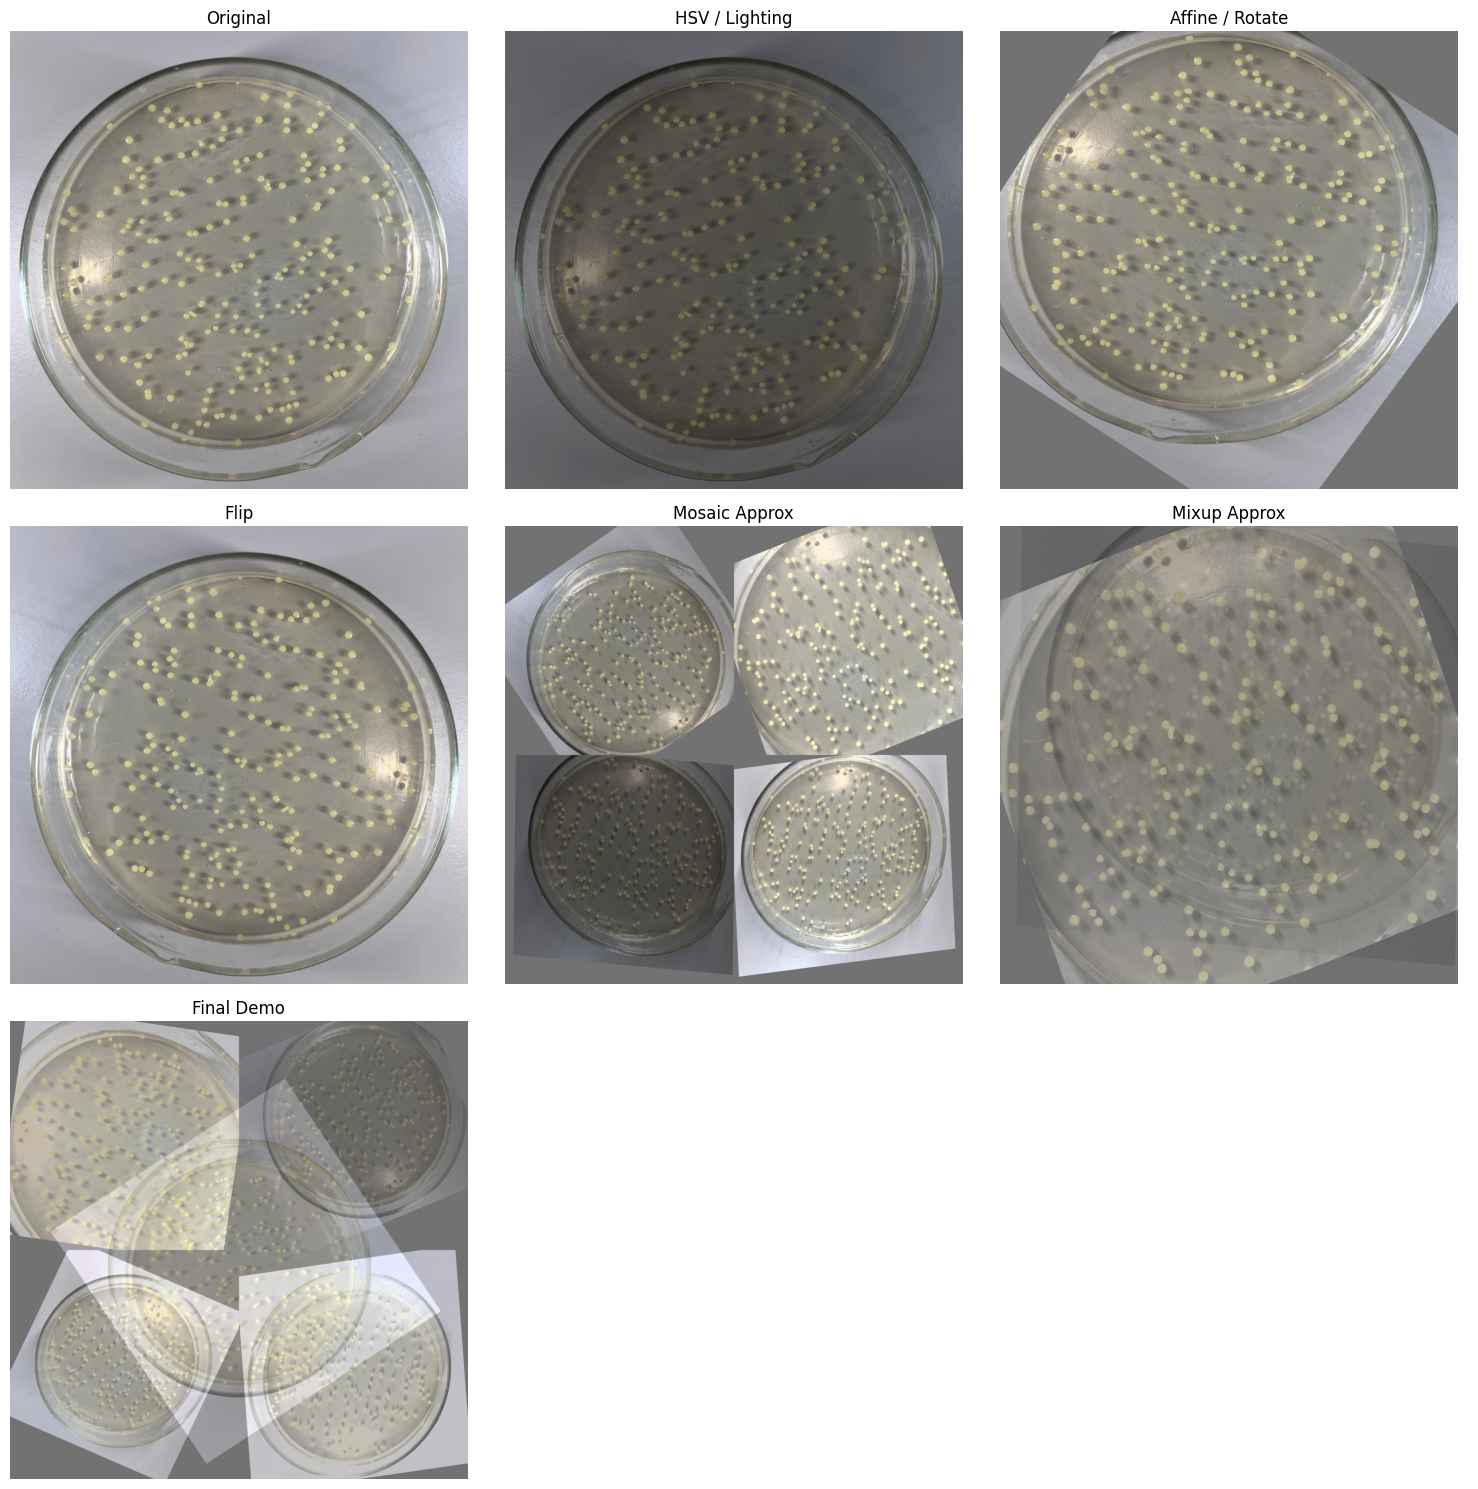

In [169]:
show_augmented_examples(IMAGE_DEMO_PATH, AUG_PARAMS, seed=DEMO_AUG_SEED)